In [64]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
load_dotenv()
engine = create_engine(os.getenv("SUPABASE_DB_URL"))

query = "SELECT * FROM weather_logs_cleaned ORDER BY timestamp ASC;"
df = pd.read_sql(query, con=engine)

# 1. Rendezés biztosítása
df = df.sort_values('timestamp').reset_index(drop=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day

weather_columns = [
    "timestamp",
    "temperature_2m",
    "relative_humidity_2m",
    "rain",
    "surface_pressure",
    "precipitation",
    "wind_speed_10m",
    "wind_direction_10m",
    "apparent_temperature",
    "cloud_cover",
    "wind_gusts_10m"
]



df = df.dropna().reset_index(drop=True)

In [50]:
weather = df[weather_columns].copy()

weather["timestamp"] = pd.to_datetime(
    weather["timestamp"]
)

weather = (
    weather
    .sort_values("timestamp")
    .drop_duplicates("timestamp")
    .reset_index(drop=True))


In [51]:
daily = (
    weather
    .set_index("timestamp")
    .resample("D")
    .agg({
        "temperature_2m": [
            "mean",
            "min",
            "max"
        ],

        "relative_humidity_2m": [
            "mean",
            "max"
        ],

        "rain": "sum",

        "surface_pressure": [
            "mean",
            "min",
            "max"
        ],

        "precipitation": [
            "sum",
            "max"
        ],

        "wind_speed_10m": [
            "mean",
            "max"
        ],

        "apparent_temperature": [
            "mean",
            "min",
            "max"
        ],

        "cloud_cover": [
            "mean",
            "max"
        ],

        "wind_gusts_10m": "max"
    })
)
daily

temperature_2m               relative_humidity_2m            rain  \
                     mean    min    max                 mean        max  sum   
timestamp                                                                      
2026-05-01      12.797917   4.10  19.45            35.629582  58.566833  0.0   
2026-05-02      16.941667   8.00  24.15            38.576229  64.257065  0.0   
2026-05-03      16.472917   9.75  22.15            37.830543  56.626133  0.0   
2026-05-04      18.552083   8.95  25.85            32.882346  61.550327  0.0   
2026-05-05      19.931250  11.85  27.40            37.551656  52.558559  0.0   
...                   ...    ...    ...                  ...        ...  ...   
2026-09-19      21.932500  16.17  27.87            39.958333  54.000000  0.0   
2026-09-20      22.865833  16.27  28.72            39.458333  57.000000  0.0   
2026-09-21      18.215652  14.57  22.22            49.913043  72.000000  0.0   
2026-09-22      14.701250  11.87  19.57            61.250000  78.000000  0.1   
2026-09-23      15.105714  10.82  21.42            61.428571  84.000000  0.0   

           surface_pressure                   precipitation       \
                       mean      min      max           sum  max   
timestamp                                                          
2026-05-01      1012.056250  1009.95  1014.03           0.0  0.0   
2026-05-02      1008.315000  1005.54  1010.71           0.0  0.0   
2026-05-03      1006.334583  1004.20  1008.24           0.0  0.0   
2026-05-04      1003.406250  1000.98  1005.78           0.0  0.0   
2026-05-05       998.634167   995.88  1001.06           0.0  0.0   
...                     ...      ...      ...           ...  ...   
2026-09-19      1008.404167  1005.50  1010.09           0.0  0.0   
2026-09-20      1008.554167  1005.40  1010.98           0.0  0.0   
2026-09-21      1007.946522  1005.52  1009.64           0.0  0.0   
2026-09-22      1007.660833  1006.66  1009.23           0.1  0.1   
2026-09-23      1008.935000  1007.75  1009.77           0.0  0.0   

           wind_speed_10m        apparent_temperature                \
                     mean    max                 mean    min    max   
timestamp                                                             
2026-05-01       6.610833  14.57             9.578333   0.49  15.19   
2026-05-02       6.860417  13.10            14.352917   5.98  21.26   
2026-05-03       9.235417  11.66            13.591250   6.36  20.22   
2026-05-04       9.310417  14.83            15.488750   6.50  22.81   
2026-05-05      12.232083  17.46            17.057500   8.92  24.63   
...                   ...    ...                  ...    ...    ...   
2026-09-19       6.705000  10.80            20.287500  13.77  26.29   
2026-09-20       6.615000  11.88            21.407917  14.89  27.07   
2026-09-21      20.128696  27.72            14.647391  11.14  20.48   
2026-09-22      17.040000  22.68            11.453333   9.04  15.49   
2026-09-23      12.368571  16.92            12.557143   8.25  17.70   

           cloud_cover        wind_gusts_10m  
                  mean    max            max  
timestamp                                     
2026-05-01   25.958333   98.0          36.36  
2026-05-02   12.875000   91.0          36.72  
2026-05-03    0.000000    0.0          32.40  
2026-05-04   15.500000   71.0          39.24  
2026-05-05   49.208333  100.0          44.28  
...                ...    ...            ...  
2026-09-19   17.375000  100.0          24.48  
2026-09-20   61.083333  100.0          27.72  
2026-09-21   38.869565  100.0          51.84  
2026-09-22   22.083333  100.0          62.64  
2026-09-23    3.000000   35.0          35.28  

[146 rows x 19 columns]

In [52]:
daily.columns = [
    f"{col}_{agg}"
    for col, agg in daily.columns
]

daily = daily.reset_index()

daily = daily.rename(
    columns={"timestamp": "date"}
)

In [53]:
daily["next_day_precipitation"] = (
    daily["precipitation_sum"]
    .shift(-1)
)

rain_threshold = 1.0

daily["target_rain_next_day"] = (
    daily["next_day_precipitation"]
    >= rain_threshold
).astype(int)

In [54]:
daily.loc[
    daily["next_day_precipitation"].isna(),
    "target_rain_next_day"
] = np.nan

In [55]:
lag_columns = [
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "surface_pressure_mean",
    "precipitation_sum",
    "cloud_cover_mean",
    "wind_speed_10m_mean",
    "wind_gusts_10m_max"
]

In [56]:
for col in lag_columns:

    for lag in [1, 2, 3, 7]:

        daily[f"{col}_lag_{lag}d"] = (
            daily[col].shift(lag)
        )

In [57]:
rolling_columns = [
    "temperature_2m_mean",
    "relative_humidity_2m_mean",
    "surface_pressure_mean",
    "precipitation_sum",
    "cloud_cover_mean"
]

for col in rolling_columns:

    shifted = daily[col].shift(1)

    daily[f"{col}_rolling_mean_3d"] = (
        shifted
        .rolling(window=3, min_periods=3)
        .mean()
    )

    daily[f"{col}_rolling_mean_7d"] = (
        shifted
        .rolling(window=7, min_periods=7)
        .mean()
    )

In [58]:
daily["precipitation_sum_rolling_3d"] = (
    daily["precipitation_sum"]
    .shift(1)
    .rolling(3, min_periods=3)
    .sum()
)

daily["precipitation_sum_rolling_7d"] = (
    daily["precipitation_sum"]
    .shift(1)
    .rolling(7, min_periods=7)
    .sum()
)

In [59]:
daily["pressure_change_1d"] = (
    daily["surface_pressure_mean"]
    - daily["surface_pressure_mean"].shift(1)
)

daily["pressure_change_3d"] = (
    daily["surface_pressure_mean"]
    - daily["surface_pressure_mean"].shift(3)
)

In [79]:
daily["temperature_change_1d"] = (
    daily["temperature_2m_mean"]
    - daily["temperature_2m_mean"].shift(1)
)
daily.dropna(inplace=True)
daily.isna().sum()


temperature_2m_mean             0
temperature_2m_min              0
temperature_2m_max              0
relative_humidity_2m_mean       0
relative_humidity_2m_max        0
                               ..
precipitation_sum_rolling_3d    0
precipitation_sum_rolling_7d    0
pressure_change_1d              0
pressure_change_3d              0
temperature_change_1d           0
Length: 64, dtype: int64

In [76]:
daily.head()

,temperature_2m_mean,temperature_2m_min,temperature_2m_max,relative_humidity_2m_mean,relative_humidity_2m_max,rain_sum,surface_pressure_mean,surface_pressure_min,surface_pressure_max,precipitation_sum,...,surface_pressure_mean_rolling_mean_7d,precipitation_sum_rolling_mean_3d,precipitation_sum_rolling_mean_7d,cloud_cover_mean_rolling_mean_3d,cloud_cover_mean_rolling_mean_7d,precipitation_sum_rolling_3d,precipitation_sum_rolling_7d,pressure_change_1d,pressure_change_3d,temperature_change_1d
10,18.258333,14.75,22.95,62.498040,78.434547,7.3,990.947917,987.16,995.53,7.3,...,1000.251845,0.066667,0.214286,56.430556,58.059524,0.2,1.5,-9.156667,-10.456667,-0.645833
11,13.400000,9.55,17.55,62.040917,92.713165,4.1,990.394167,986.96,994.75,4.1,...,998.472083,2.433333,1.257143,64.694444,66.601190,7.3,8.8,-0.553750,-12.079583,-4.858333
12,12.833333,6.90,19.25,43.289867,66.077293,0.0,994.124167,991.92,995.67,0.0,...,997.294940,3.800000,1.842857,69.819444,72.154762,11.4,12.9,3.730000,-5.980417,-0.566667
13,15.022917,6.80,20.65,44.570449,80.905098,0.0,990.414167,987.38,993.15,0.0,...,996.934643,3.800000,1.814286,61.666667,63.952381,11.4,12.7,-3.710000,-0.533750,2.189583
14,15.189583,11.50,20.90,62.848233,93.014694,5.4,988.276250,986.54,989.37,5.4,...,995.694762,1.366667,1.657143,52.847222,57.589286,4.1,11.6,-2.137917,-2.117917,0.166667


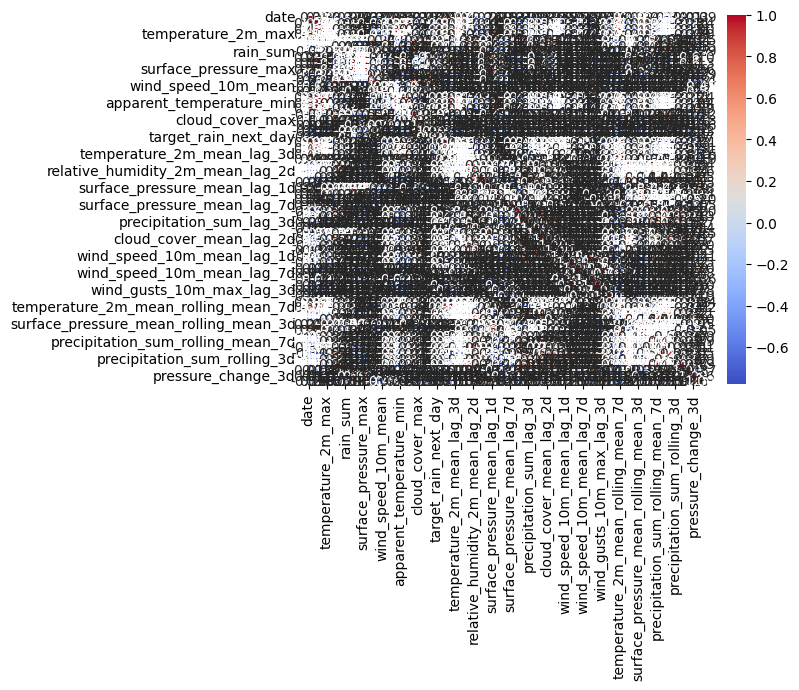

In [68]:
plt.figure()
sns.heatmap(
    daily.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
)
plt.show()

In [77]:
table_name = "weather_logs_features_test"
daily.to_sql(
    name=table_name,
    con=engine,
    if_exists="replace",  # ha már létezik a tábla, írja felül (futtathatod többször is)
    index=False,           # ne mentse el a pandas indexet külön oszlopként
    method="multi"         # felgyorsítja a nagy mennyiségű adat beszúrását
)

127